# Исследование эффективности алгоритмов

In [13]:
import numpy as np
import osmnx as ox
import geopandas as gpd
import networkx as nx

import matplotlib.pyplot as plt

from graphs.algorithms import generate_grid_graph, remove_edges_intersecting_lines, remove_nodes_in_polygons, update_speeds_on_random_routes
from shapely.geometry import LineString, Polygon

# 1. Подготовка рабочего графа

В исследовании применяется граф представляющий собой решетку размером 100х100 и шагом 100м. Каждый узел графа соединяется со всеми соседними узлами расположенными ортогонально и по диагонали от него (окрестность Мура). При этом расстояние до диагонально расположенных узлов составляет:

$l_{диаг} = l_{орт} * \sqrt{2} = 100 * 1.41 = 141.42$

Из графа удален ряд узлов ограниченных некоторыми областями имитирующими естественные преграды (реки, овраги, железнодорожное полотно и т.д.).

Скорость движения пожарных автомобилей по большей части дорог принята как 20 км/ч. При этом в графе имеются 10 узлов соединенных дорогами со скоростями 50км/ч, отражающими крупные автомагистрали и 30 узлов соединенных дорогами со скоростью движения 35 км/ч, представляющими дороги районного значения.

Таким образом смоделирован граф достаточно полно отражающий особенности реальных графов дорожной сети и при этом достаточно небольшой для использования его в качестве модельного примера.

<Axes: >

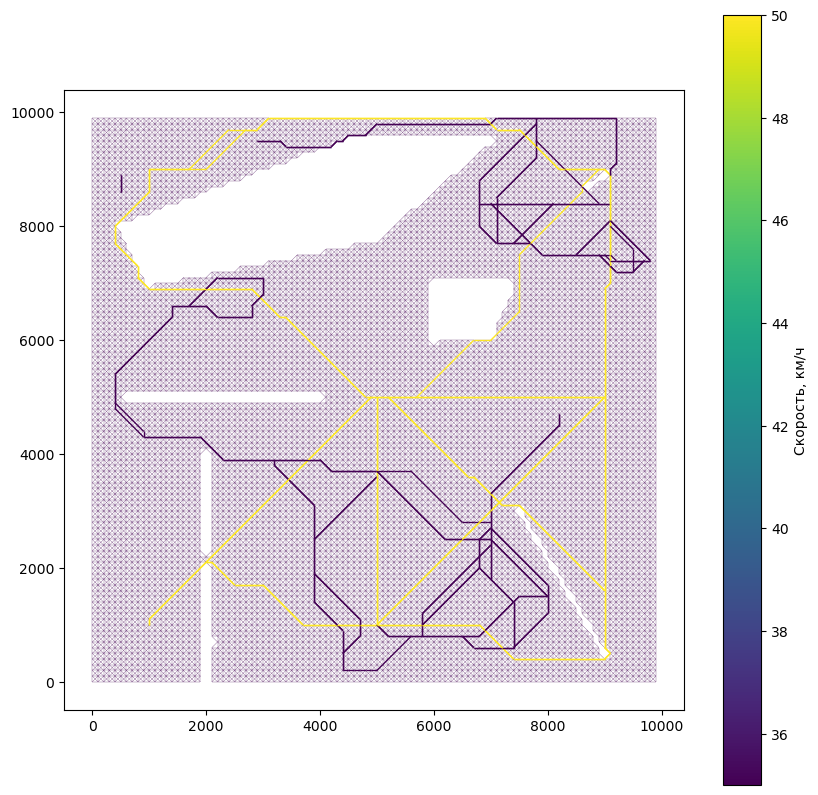

In [14]:
G = generate_grid_graph(n=100, m=100, step=100.0, speed=20.0, diagonals=True)
nx.set_edge_attributes(G, 'undefined', 'highway')

lines = [
    LineString([(2000, -50), (2000, 2050)]),  # Вертикальная линия
    LineString([(2000, 2300), (2000, 4050)]),
    LineString([(550, 5000), (4000, 5000)]),  # Горизонтальная линия
    LineString([(9000, 500), (7500, 3000)]),
    LineString([(2000, 500), (2100, 700)]),
    LineString([(9000, 8900), (8700, 8700)]),
]
G = remove_edges_intersecting_lines(G, lines)

polygons_to_remove = [
    Polygon([(6000, 6000), (6500, 6100), (7000, 6100), (7300, 6800), (7300, 7000), (6000, 7000)]),
    Polygon([(500, 8000), (4500, 9500), (7000, 9500), (5000, 7800), (1000, 7000)])   
]
G = remove_nodes_in_polygons(G, polygons_to_remove)

# Добавляем средние автомагистрали
G = update_speeds_on_random_routes(G,
                                    num_nodes           = 30,
                                    max_route_length    = 2500,
                                    max_routes_per_node = 5,
                                    speed               = 35,
                                    seed                = 2,
                                    )
# Добавляем крупные автомагистрали
# G = update_speeds_on_random_routes(G,
#                                     num_nodes           = 10,
#                                     max_route_length    = 5000,
#                                     max_routes_per_node = 5,
#                                     speed               = 50,
#                                     seed                = 2,
#                                     )
G = update_speeds_on_random_routes(G,
                                    num_nodes           = 10,
                                    max_route_length    = 7500,
                                    max_routes_per_node = 5,
                                    speed               = 50,
                                    seed                = 2,
                                    selected_nodes = [1010, 1050, 1090, 5010, 5050, 5099, 9010, 9050, 9090]
                                    )







g_nodes, g_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
ax = g_edges.query('speed_kph == 20').plot(column='speed_kph', figsize=(10, 10), 
            linewidth = 0.1, 
            cmap='viridis', 
            # legend=True, 
            # legend_kwds={'label': "Скорость, км/ч"},
            )
g_edges.query('speed_kph > 20').plot(column='speed_kph',
            ax=ax,
            linewidth = 1,
            cmap='viridis',
            legend=True,
            legend_kwds={'label': "Скорость, км/ч"},
            )

<Axes: >

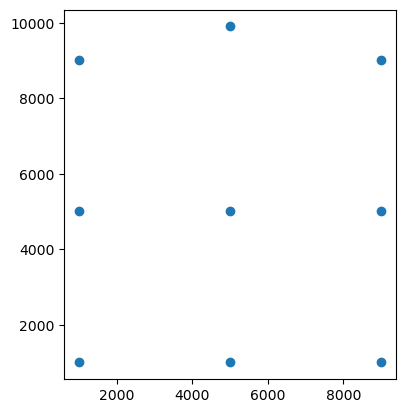

In [15]:
g_nodes.loc[[1010, 1050, 1090, 5010, 5050, 5099, 9010, 9050, 9090]].plot()

C:\Users\Obsidian\AppData\Local\Temp\ipykernel_10380\1987005867.py:19: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  g_nodes.query('arrival_time>20').plot(ax=ax, color='r', label='Тпр > 20', marker='s', legend=True)


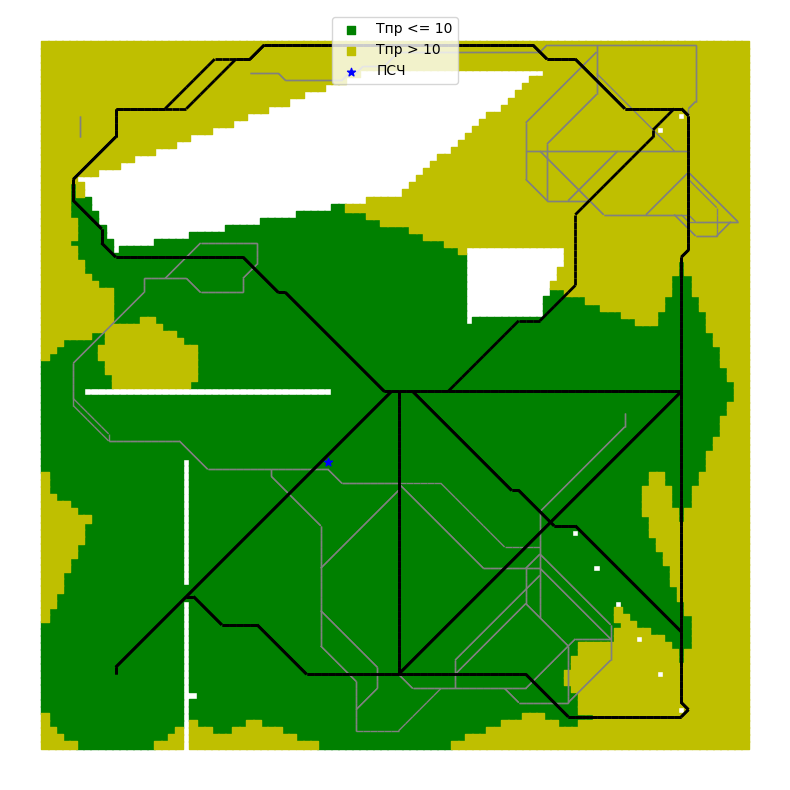

     Среднее время прибытия:  9.0 мин.
Максимальное время прибытия:  18.2 мин.
                      ИП-10:  62.89127308926004 %
                      ИП-10:  99.0819599601814 %


In [16]:
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex

units = {
    4040: 'ПСЧ-1',
    # 7020: 'ПСЧ-2',
    }

times, _ = FirstArrivalUnitState()(G, units)

g_nodes, g_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
g_nodes['arrival_time'] = times

def print_results(g_nodes, g_edges, units, figsize=(10,10)):
    # Печать карты
    fig, ax = plt.subplots(1,1, figsize=figsize)
    g_nodes.query('arrival_time<=10').plot(ax=ax, color='g', label='Тпр <= 10', marker='s', legend=True)
    g_nodes.query('arrival_time<=20 and arrival_time>10').plot(ax=ax, color='y', label='Тпр > 10', marker='s', legend=True)
    g_nodes.query('arrival_time>20').plot(ax=ax, color='r', label='Тпр > 20', marker='s', legend=True)
    g_nodes.loc[units.keys()].plot(ax=ax, color='b', label='ПСЧ', marker='*', legend=True)
    g_edges.query('speed_kph == 35').plot(ax=ax, color='grey', linewidth=1)
    g_edges.query('speed_kph == 50').plot(ax=ax, color='k', linewidth=2)
    ax.axis('off')
    ax.legend()
    plt.show()

    # Печать метрик
    print('     Среднее время прибытия: ', round(ArrivalTime()(times), 1), 'мин.')
    print('Максимальное время прибытия: ', round(ArrivalTime(np.max)(times), 1), 'мин.')
    print('                      ИП-10: ', CoverIndex(10)(g_nodes['arrival_time']), '%')
    print('                      ИП-10: ', CoverIndex(20)(g_nodes['arrival_time']), '%')

print_results(g_nodes, g_edges, units)